# Where the loss is highest, and whether the labels are at fault

Every window in the dataset, ranked by its own loss, drawn worst first, for **train, val and
test alike**. The point is not model quality - it is to look at what the model finds hardest
and ask whether the label is right.

**No window is scored by a model that trained on it.** The folds partition the train pool, so
each window is validation in exactly one fold and that fold's model never saw it; test windows
are held out of every fold and get the ensemble. Without this the train rows would look easy
for the wrong reason and a mislabelled window would hide inside a memorised one.

In [1]:
import sys
from pathlib import Path


def repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'phase').is_dir():
            return candidate
    raise RuntimeError(f'no inhale-exhale-training checkout at or above {start}')


REPO = repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

try:
    import torch
except ModuleNotFoundError as missing:
    raise RuntimeError(
        f'{missing.name} is missing - select the inhale-exhale-training kernel') from missing
print(f'repo root {REPO}')

repo root /Users/yaelalon/inhale-exhale-training


In [2]:
import numpy as np
import pandas as pd
import torch.nn.functional as F
from IPython.display import Image
from omegaconf import OmegaConf

from models.lightning_module import PhaseSegmenter
from phase import figures
from phase.building import load_windows, shard_path
from phase.decode import decode
from phase.labels import EXHALE, INHALE, PHASES
from phase.splits import FOLD_COLUMN, SPLIT_COLUMN

PLOT = OmegaConf.to_container(OmegaConf.load(REPO / 'parameter' / 'config.yaml').plot,
                              resolve=True)
OUT = REPO / 'out' / 'high_loss'

# Set RUN_NAME to audit a particular run; None takes the newest FINISHED one.
# `dataset.txt` is written when a fold completes, so requiring it skips a run still
# training - otherwise starting an ablation silently redirects this audit.
RUN_NAME = None                            # None takes the newest COMPLETE run

# Both layouts: Hydra writes `outputs/<date>/<time>/`, older runs are `outputs/run_*`.
# A run counts as complete only when every fold it started has written `dataset.txt`, so a run
# still training is skipped rather than audited half-built.
def complete(run):
    folds = sorted(run.glob('fold_*'))
    return bool(folds) and all((f / 'dataset.txt').is_file() for f in folds)


runs = sorted((r for r in [*(REPO / 'outputs').glob('*'), *(REPO / 'outputs').glob('*/*')]
               if r.is_dir() and complete(r)),
              key=lambda r: (r / 'fold_0' / 'dataset.txt').stat().st_mtime)
if RUN_NAME:
    RUN = REPO / 'outputs' / RUN_NAME
    if not (RUN / 'fold_0' / 'dataset.txt').is_file():
        raise FileNotFoundError(f'{RUN} has no finished fold_0')
elif not runs:
    raise FileNotFoundError('no finished run under outputs/')
else:
    RUN = runs[-1]
DATASET = Path((RUN / 'fold_0' / 'dataset.txt').read_text().strip())
if not DATASET.is_absolute():
    DATASET = REPO / DATASET

manifest = load_windows(DATASET)
print(f'run     {RUN.name}   (other finished: '
      f'{", ".join(r.name for r in runs[-4:-1]) or "none"})')
print(f'dataset {DATASET.name}  -  {len(manifest)} windows')
print(manifest[SPLIT_COLUMN].value_counts().to_dict())


run     10-23-34   (other finished: 17-32-36, 17-58-30, 18-27-43)
dataset phases_human_20260826T111543Z  -  1081 windows
{'train': 853, 'test': 228}


## The models

One checkpoint per fold, the epoch each fold's own validation score picked.

In [3]:
folds = {}
for path in sorted(RUN.glob('fold_*/checkpoints/*.ckpt')):
    fold = int(path.parent.parent.name.split('_')[1])
    model = PhaseSegmenter.load_from_checkpoint(path, map_location='cpu')
    model.eval()
    folds[fold] = model
print(f'{len(folds)} folds: ' + ', '.join(f'{k} ({p.name})' for k, p in
      zip(folds, sorted(RUN.glob('fold_*/checkpoints/*.ckpt')))))
FPS = float(manifest['analysis_fps'].median())

5 folds: 0 (best-epoch=35.ckpt), 1 (best-epoch=20.ckpt), 2 (best-epoch=30.ckpt), 3 (best-epoch=25.ckpt), 4 (best-epoch=08.ckpt)


## Which model judges which window

A window in the train pool is validation in exactly one fold - that fold trained without it,
so it is the one that may score it. Test windows are outside every fold's training set, so
they get all five averaged.

In [4]:
def roles_of(row) -> list[tuple[str, list[int]]]:
    """Every (role, judging folds) pair for one window.

    `split` holds only train/test - validation is per fold. A train-pool window is
    validation in exactly one fold, so that fold judges it out of fold; it is also
    training data for the other four, and scoring it with one of those says what a
    memorised window looks like. Both are reported, labelled for what they are.
    """
    if row[SPLIT_COLUMN] == 'test':
        return [('test', sorted(folds))]
    held_out = [k for k in folds if row.get(FOLD_COLUMN.format(fold=k)) == 'val']
    trained_on = [k for k in folds if row.get(FOLD_COLUMN.format(fold=k)) == 'train']
    pairs = []
    if held_out:
        pairs.append(('val', held_out))
    if trained_on:
        pairs.append(('train', trained_on[:1]))
    return pairs


def trace_of(row):
    with np.load(shard_path(DATASET, str(row['shard'])), allow_pickle=False) as stored:
        position = int(row['position'])
        start, end = stored['offsets'][position], stored['offsets'][position + 1]
        return (stored['values'][start:end].astype(np.float32),
                stored['targets'][start:end].astype(np.int64))


def normalise(values):
    centred = values - values.mean()
    scale = centred.std()
    return centred / scale if scale > 1e-8 else centred


def polarity(values, target):
    """Does inhale rise here? Falling inhale is the signature of an inverted label set."""
    step = np.diff(values.astype(float))
    rising = (target[:-1] == INHALE) & (target[1:] == INHALE)
    falling = (target[:-1] == EXHALE) & (target[1:] == EXHALE)
    if rising.sum() < 3 or falling.sum() < 3:
        return None
    return bool(step[rising].mean() > step[falling].mean())


In [5]:
rows = []
for _, row in manifest.iterrows():
    values, target = trace_of(row)
    x = torch.from_numpy(normalise(values)[None, None, :])
    rises = polarity(values, target)
    for role, judges in roles_of(row):
        with torch.no_grad():
            logits = torch.stack([folds[k](x)[0] for k in judges]).mean(0)
        truth = torch.from_numpy(target)[None, :]
        # Unweighted mean cross-entropy: comparable between windows, which the
        # class-weighted training loss is not.
        loss = float(F.cross_entropy(logits[None, ...], truth).item())
        prediction = decode(logits.permute(1, 0).numpy(), folds[judges[0]].cost,
                            folds[judges[0]].min_duration)
        rows.append({'role': role, 'loss': loss,
                     'macro_f1': figures.score(prediction, target),
                     'inhale_rises': rises,
                     'patient': row['PatientID'], 'study': row.get('study'),
                     'env': row['env'], 'window': int(row['RespirationWindowID']),
                     'signal': int(row['RadarSignalID']),
                     'session': int(row['SessionID']),
                     'window_index': int(row['WindowIndex']),
                     'flipped': bool(row['reviewer_flipped']),
                     'samples': int(row['samples']),
                     'judged_by': '+'.join(str(k) for k in judges),
                     'values': values, 'target': target, 'prediction': prediction,
                     'fps': float(row['analysis_fps'])})

scored = pd.DataFrame(rows).sort_values('loss', ascending=False).reset_index(drop=True)
table = scored.drop(columns=['values', 'target', 'prediction'])
OUT.mkdir(parents=True, exist_ok=True)
table.to_csv(OUT / 'window_loss.csv', index=False)
print('train = judged by a fold that TRAINED on it (memorised)')
print('val   = judged by the one fold that held it out')
print('test  = judged by all five, none of which saw it\n')
table.groupby('role')['loss'].describe()[['count', 'mean', '50%', 'max']].round(3)


train = judged by a fold that TRAINED on it (memorised)
val   = judged by the one fold that held it out
test  = judged by all five, none of which saw it



,count,mean,50%,max
role,,,,
test,228.0,0.396,0.293,2.434
train,853.0,0.290,0.250,1.757
val,853.0,0.437,0.342,3.389


## The suspects

Two things worth separating before looking at any picture.

**Inverted polarity** - `inhale` labelled on the falling edge. Whatever the cause, the model
cannot be right and wrong at once, so these are label problems rather than model problems.

**All-unknown windows** - the labeller called nothing. A model that agrees still scores near
zero macro F1, because three of four classes are absent from the window. Those are metric
artefacts, not errors, and they should not be read as failures.

In [6]:
inverted = table[table.inhale_rises == False]                       # noqa: E712
print(f'inverted polarity: {inverted.window.nunique()} windows, '
      f'{len(inverted)} (window, role) rows')
print(inverted[['role', 'patient', 'env', 'window', 'signal', 'session', 'window_index',
                'flipped', 'loss', 'macro_f1']].to_string(index=False))

all_unknown = [i for i, r in scored.iterrows()
               if (r['target'] == PHASES.index('unknown')).all()]
if all_unknown:
    print(f'\nentirely unknown: {scored.loc[all_unknown, "window"].nunique()} windows, '
          f'median macro F1 {scored.loc[all_unknown, "macro_f1"].median():.2f} - correct, '
          f'and scored badly because three of four classes are absent')
else:
    print('\nentirely unknown: none')


inverted polarity: 1 windows, 2 (window, role) rows
 role patient     env  window   signal  session  window_index  flipped     loss  macro_f1
  val  bs-005 ds_prod     485 16882043     2361             2    False 2.375932  0.191901
train  bs-005 ds_prod     485 16882043     2361             2    False 1.756972  0.196396

entirely unknown: 151 windows, median macro F1 1.00 - correct, and scored badly because three of four classes are absent


## The worst windows, per split

Shading is the model, ribbon is the labeller. Titles carry the signal and session so a window
can be opened in the labelling app.

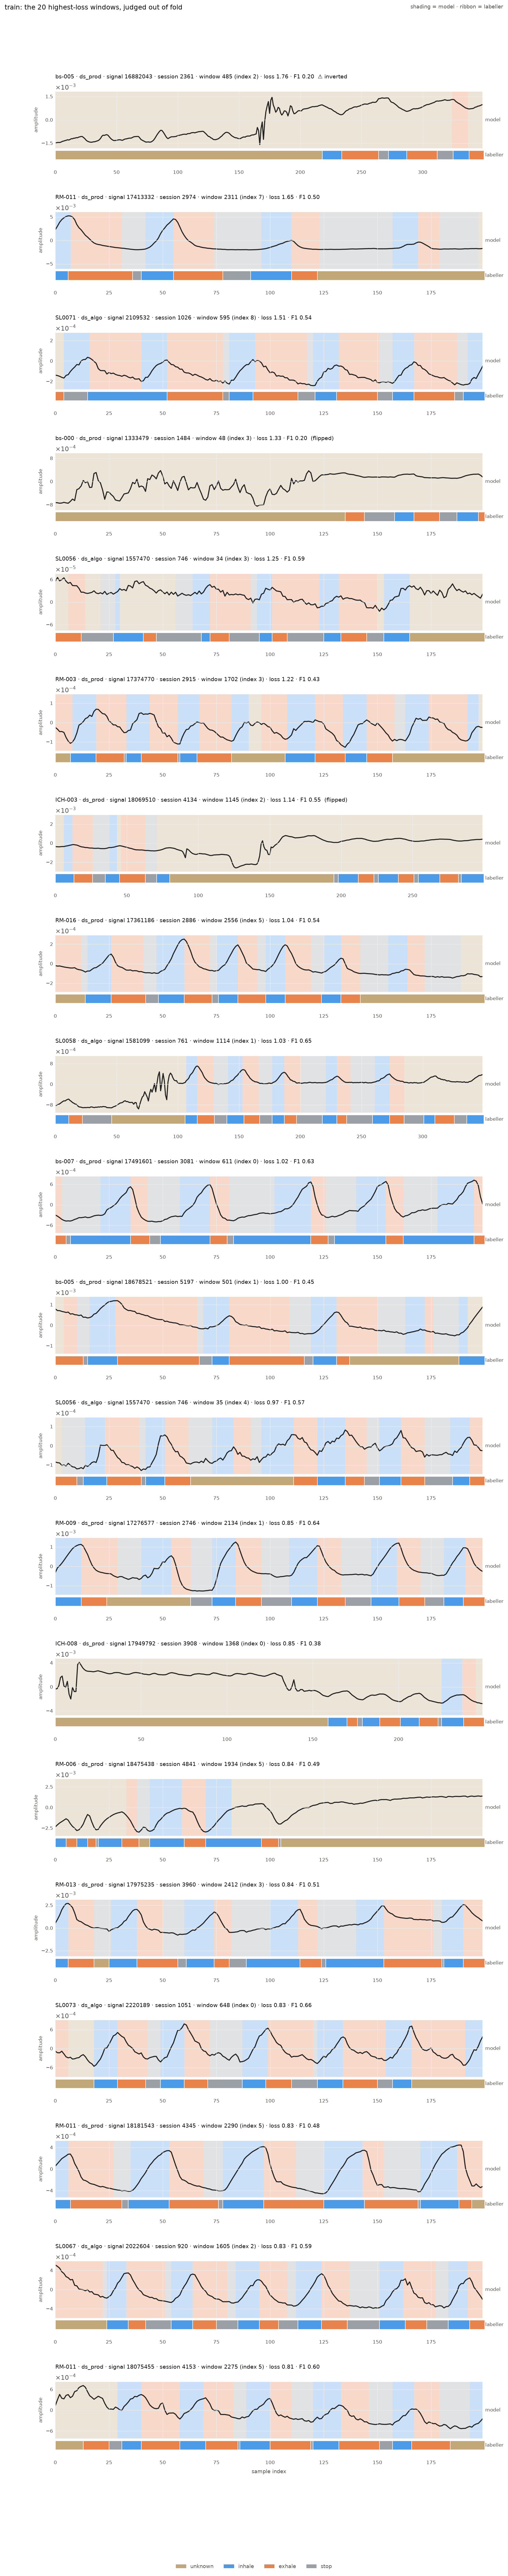

In [7]:
WORST = 20


def title_of(r) -> str:
    """Enough to find the window in the labelling app: signal, session, and its index
    within that signal - the window id alone is not unique across instances."""
    return (f"{r['patient']} · {r['env']} · signal {r['signal']} · "
            f"session {r['session']} · window {r['window']} (index {r['window_index']})"
            f" · loss {r['loss']:.2f} · F1 {r['macro_f1']:.2f}"
            + ('  ⚠ inverted' if r['inhale_rises'] is False else '')
            + ('  (flipped)' if r['flipped'] else ''))


def draw(split: str, n: int = WORST):
    part = scored[scored.role == split].head(n)
    if part.empty:
        return None
    panels = [{'values': r['values'], 'reference': r['target'],
               'prediction': r['prediction'], 'fps': r['fps'], 'title': title_of(r)}
              for _, r in part.iterrows()]
    out = figures.plot_windows(
        panels, OUT / f'worst_{split}.png',
        f'{split}: the {len(panels)} highest-loss windows, judged out of fold',
        'labeller', PLOT, prediction_name='model',
        caption='shading = model · ribbon = labeller')
    return Image(filename=str(out))


draw('train')


### val

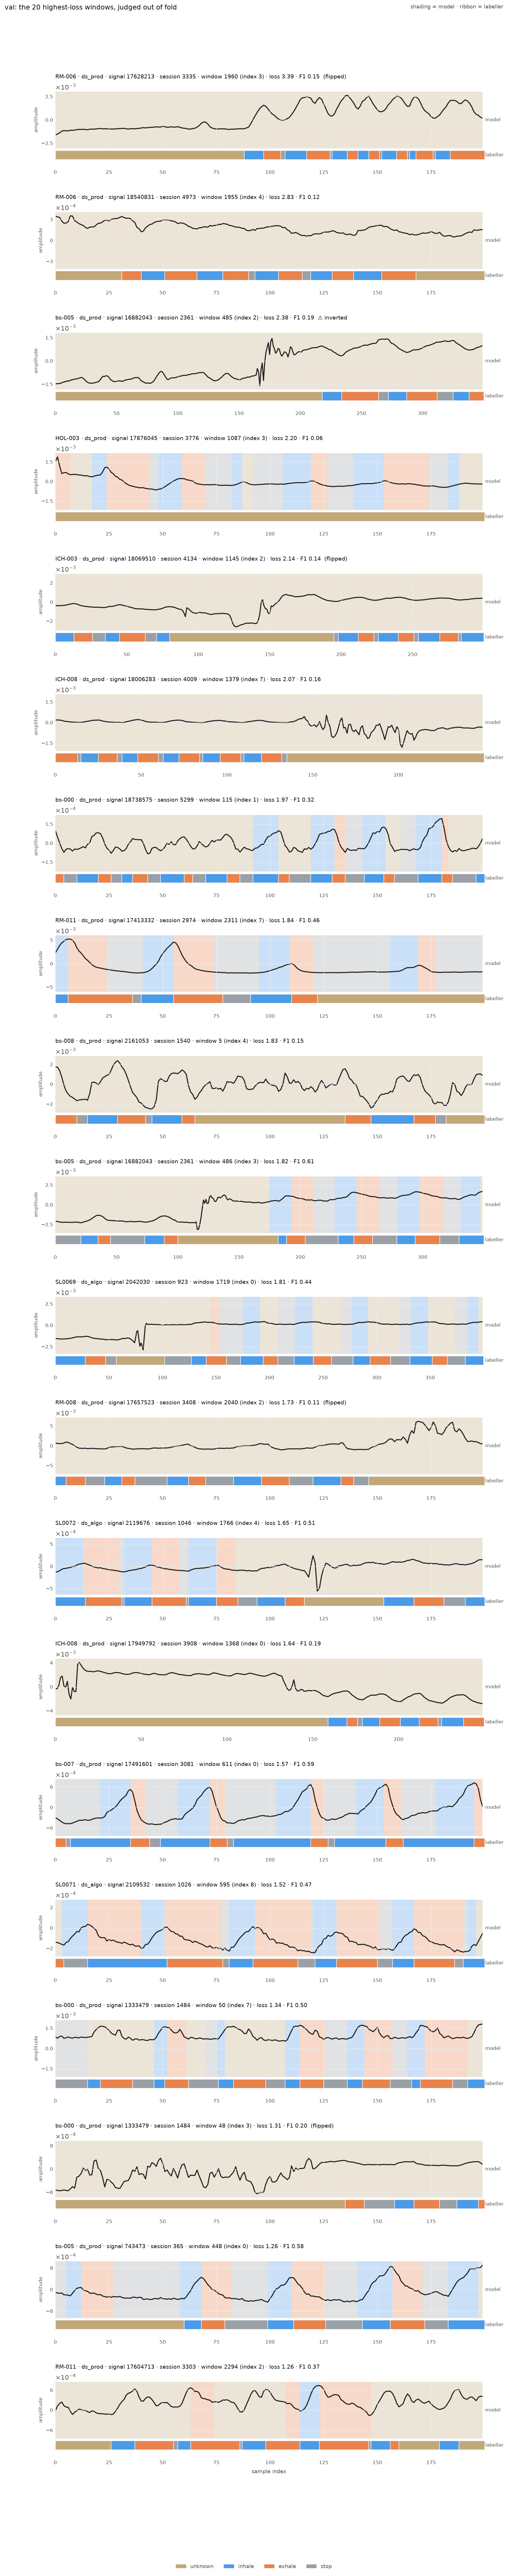

In [8]:
draw('val')

### test

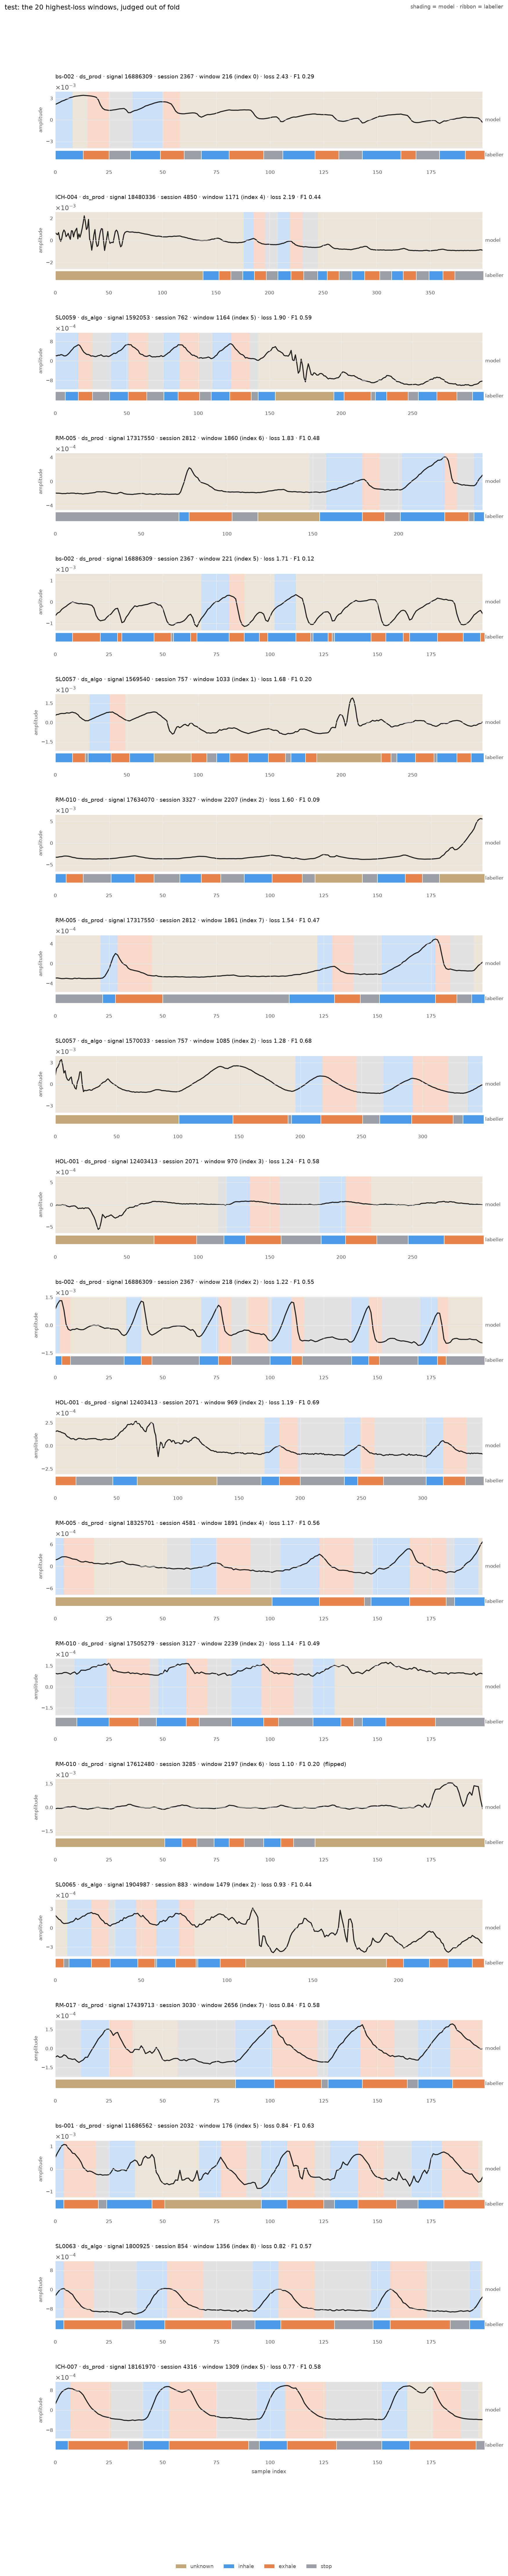

In [9]:
draw('test')

## Is high loss a labelling problem or a hard window?

If the inverted windows sit at the top of the loss ranking, the ranking is finding label
errors. If they are scattered, high loss is mostly genuine difficulty and the pictures above
have to be read one at a time.

In [10]:
ranks = table.reset_index().rename(columns={'index': 'rank'})
flagged = ranks[ranks.inhale_rises == False]                        # noqa: E712
print(f'{len(flagged)} inverted windows sit at loss ranks: '
      f'{sorted(flagged["rank"].tolist())}  (0 = highest loss of {len(ranks)})')
print(f'median rank {flagged["rank"].median():.0f} of {len(ranks)}')
print()
print('mean loss, inverted vs the rest:')
print(table.assign(inverted=table.inhale_rises == False)                # noqa: E712
      .groupby('inverted')['loss'].agg(['count', 'mean', 'median']).round(3).to_string())

2 inverted windows sit at loss ranks: [3, 15]  (0 = highest loss of 1934)
median rank 9 of 1934

mean loss, inverted vs the rest:
          count   mean  median
inverted                      
False      1932  0.366   0.296
True          2  2.066   2.066
